# 02b - Oracle Context Evaluation

Questo notebook valuta tutto il dataset di partenza in quattro condizioni controllate:

- `mcq_no_context`: domanda a scelta multipla senza contesto, scoring deterministico sulla label.
- `mcq_oracle_context`: domanda a scelta multipla con gli articoli source-of-truth citati nel dataset.
- `no_hint_no_context`: domanda aperta senza alternative, valutata da LLM-as-a-judge.
- `no_hint_oracle_context`: domanda aperta con gli articoli source-of-truth citati nel dataset, valutata da LLM-as-a-judge.

Lo scopo non è misurare retrieval, ma solo quanto migliora il modello quando riceve il contesto corretto già indicato dal dataset.

In [1]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path
from datetime import datetime

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve()
while not (ROOT / 'pyproject.toml').exists():
    if ROOT.parent == ROOT:
        raise RuntimeError('Project root not found')
    ROOT = ROOT.parent

SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from legal_rag.oracle_context_evaluation import McqAnswerOutput, OracleEvaluationConfig, build_oracle_contexts, create_default_client, discover_utopia_api_models, discover_utopia_models, run_oracle_context_evaluation
from legal_rag.oracle_context_evaluation.env import load_env_file, resolve_env_file
from legal_rag.oracle_context_evaluation.io import read_jsonl
from legal_rag.oracle_context_evaluation.models import DEFAULT_CHAT_MODEL
from legal_rag.oracle_context_evaluation.prompts import schema_dict
from legal_rag.oracle_context_evaluation.runner import resolve_answer_model, resolve_utopia_runtime, validate_mcq_no_hint_alignment

ENV_FILE = resolve_env_file(ROOT / '.env') or (ROOT / '.env')
load_env_file(ENV_FILE)

EVALUATION_DIR = ROOT / 'data' / 'evaluation_clean'
LAWS_DIR = ROOT / 'data' / 'laws_dataset_clean'
OUTPUT_DIR = ROOT / 'data' / 'evaluation_runs' / 'oracle_context'

mcq_records = read_jsonl(EVALUATION_DIR / 'questions_mcq.jsonl')
no_hint_records = read_jsonl(EVALUATION_DIR / 'questions_no_hint.jsonl')
contexts = build_oracle_contexts(no_hint_records, LAWS_DIR)
validate_mcq_no_hint_alignment(mcq_records, no_hint_records)

article_reference_count = sum(len(ctx.expected_references) for ctx in contexts)
resolved_reference_count = sum(len(ctx.resolved_references) for ctx in contexts)
context_error_count = sum(1 for ctx in contexts if ctx.error)

print(json.dumps({
    'mcq_questions': len(mcq_records),
    'no_hint_questions': len(no_hint_records),
    'oracle_context_rows': len(contexts),
    'article_references': article_reference_count,
    'resolved_article_references': resolved_reference_count,
    'context_errors': context_error_count,
}, ensure_ascii=False, indent=2))

assert len(mcq_records) == len(no_hint_records) == len(contexts)
assert context_error_count == 0


{
  "mcq_questions": 100,
  "no_hint_questions": 100,
  "oracle_context_rows": 100,
  "article_references": 106,
  "resolved_article_references": 106,
  "context_errors": 0
}


## Esempi

Il no-hint usa la stessa domanda del dataset MCQ, ma senza alternative. Il contesto oracle contiene solo gli articoli citati dal campo `expected_references`, nell'ordine del dataset.

In [2]:
sample_index = 4
sample_mcq = mcq_records[sample_index]
sample_no_hint = no_hint_records[sample_index]
sample_context = contexts[sample_index]

print('MCQ question')
print(sample_mcq['question_stem'])
print()
print('MCQ options')
print(json.dumps(sample_mcq['options'], ensure_ascii=False, indent=2))
print()
print('Correct label')
print(sample_mcq['correct_label'])

print()
print('No-hint question')
print(sample_no_hint['question'])
print()
print('Official correct answer')
print(sample_no_hint['correct_answer'])

print()
print('Source-of-truth references')
print(json.dumps(sample_context.expected_references, ensure_ascii=False, indent=2))
print()
print('Resolved article IDs')
print(json.dumps(sample_context.context_article_ids, ensure_ascii=False, indent=2))
print()
print('Oracle article context preview')
print(sample_context.context_text[:1800])


MCQ question
Da quanti membri è composta la Consulta regionale per la mobilità ciclistica?

MCQ options
{
  "A": "Tale organo non esiste",
  "B": "15 membri estratti a sorte tra i cittadini",
  "C": "Dal Presidente della Giunta Regionale e da un assessore",
  "D": "Da 7 membri",
  "E": "Dai membri eletti dalla Federazione ciclistica nazionale",
  "F": "Da almeno 3 ciclisti professionisti"
}

Correct label
D

No-hint question
Da quanti membri è composta la Consulta regionale per la mobilità ciclistica?

Official correct answer
Da 7 membri

Source-of-truth references
[
  "Legge regionale 8 ottobre 2019, n. 16 - Art. 4 bis",
  "Legge regionale 7 ottobre 2024, n. 19 - Art. 2"
]

Resolved article IDs
[
  "vda:lr:2019-10-08:16#art:4bis",
  "vda:lr:2024-10-07:19#art:2"
]

Oracle article context preview
[1] Legge regionale 8 ottobre 2019, n. 16 - Testo vigente
Article: 4bis
(Consulta regionale per la mobilità ciclistica) (3)
1. Con decreto dell'assessore regionale competente in materia di mobi

## Preflight Utopia

Esegui questa cella prima del benchmark completo. Fa una sola chiamata strutturata al server Utopia/Ollama con lo stesso schema JSON usato nelle run MCQ. Il default torna al base model `SLURM.gpt-oss:120b`; puoi sovrascriverlo con `UTOPIA_CHAT_MODEL` o cambiando `CHAT_MODEL` nella cella.


In [3]:
RUN_UTOPIA_PREFLIGHT = True
PREFLIGHT_TIMEOUT_SECONDS = 60
API_MODE = os.getenv('UTOPIA_CHAT_API_MODE', 'ollama')
CHAT_MODEL = os.getenv('UTOPIA_CHAT_MODEL') or DEFAULT_CHAT_MODEL
JUDGE_MODEL = os.getenv('UTOPIA_JUDGE_MODEL') or None
API_URL = (
    os.getenv('UTOPIA_CHAT_COMPLETIONS_URL')
    if API_MODE == 'openai'
    else os.getenv('UTOPIA_OLLAMA_CHAT_URL')
) or None

if RUN_UTOPIA_PREFLIGHT:
    preflight_config = OracleEvaluationConfig(
        evaluation_dir=str(EVALUATION_DIR),
        laws_dir=str(LAWS_DIR),
        output_dir=str(OUTPUT_DIR),
        env_file=str(ENV_FILE),
        api_key=os.getenv('UTOPIA_API_KEY') or None,
        api_url=API_URL,
        base_url=os.getenv('UTOPIA_BASE_URL', 'https://utopia.hpc4ai.unito.it/api'),
        api_mode=API_MODE,
        chat_model=CHAT_MODEL,
        judge_model=JUDGE_MODEL,
        timeout_seconds=PREFLIGHT_TIMEOUT_SECONDS,
    )
    runtime = resolve_utopia_runtime(preflight_config)
    answer_model = resolve_answer_model(preflight_config)
    api_catalog = discover_utopia_api_models(
        base_url=runtime['base_url'],
        api_key=runtime['api_key'],
        timeout_seconds=10,
    )
    ollama_catalog = discover_utopia_models(
        api_url=runtime['api_url'],
        api_key=runtime['api_key'],
        timeout_seconds=10,
    )
    available_models = sorted(
        set(api_catalog.get('all_models') or api_catalog.get('models') or [])
        | set(ollama_catalog.get('models') or [])
    )

    print(json.dumps({
        'api_mode': runtime['api_mode'],
        'api_url': runtime['api_url'],
        'configured_model': answer_model,
        'catalog_ok': bool(api_catalog.get('ok') or ollama_catalog.get('ok')),
        'available_models': available_models,
        'api_catalog_error': api_catalog.get('error'),
        'ollama_catalog_error': ollama_catalog.get('error'),
    }, ensure_ascii=False, indent=2))

    if available_models and answer_model not in set(available_models):
        raise RuntimeError(
            f"Configured model {answer_model!r} is not listed by Utopia. "
            f"Set CHAT_MODEL or UTOPIA_CHAT_MODEL to one of: {available_models}"
        )

    preflight_client = create_default_client(preflight_config)
    preflight_call = preflight_client.structured_chat(
        prompt='Rispondi scegliendo esattamente la label A. Restituisci solo JSON valido.',
        model=answer_model,
        payload_schema=schema_dict(McqAnswerOutput),
        timeout_seconds=PREFLIGHT_TIMEOUT_SECONDS,
    )
    preflight_output = McqAnswerOutput.model_validate(preflight_call['structured'])
    print(json.dumps({
        'status': 'ok',
        'model': answer_model,
        'structured_output': preflight_output.model_dump(mode='json'),
    }, ensure_ascii=False, indent=2))
else:
    print('Preflight Utopia saltato.')


{
  "api_mode": "ollama",
  "api_url": "https://utopia.hpc4ai.unito.it/ollama/api/chat",
  "configured_model": "code",
  "catalog_ok": true,
  "available_models": [
    "SLURM.deepseek-r1:70b-llama-distill-q8_0",
    "SLURM.gemma3:27b-it-fp16",
    "SLURM.gpt-oss:120b",
    "SLURM.gpt-oss:20b",
    "SLURM.mxbai-embed-large:latest",
    "SLURM.nomic-embed-text:latest",
    "SLURM.qwen3-coder-next:q8_0",
    "SLURM.qwen3-embedding:latest",
    "SLURM.qwen3:32b-fp16-utopia",
    "chat",
    "code",
    "deepseek-r1:70b-llama-distill-q8_0",
    "gemma3:27b-it-fp16",
    "genimage",
    "gpt-oss:120b",
    "gpt-oss:20b",
    "johnny-english",
    "mxbai-embed-large:latest",
    "nomic-embed-text:latest",
    "qwen3-coder-next:q8_0",
    "qwen3-embedding:latest",
    "qwen3:32b-fp16-utopia"
  ],
  "api_catalog_error": null,
  "ollama_catalog_error": null
}
{
  "status": "ok",
  "model": "code",
  "structured_output": {
    "answer_label": "A",
    "short_rationale": null
  }
}


## Esecuzione Benchmark

Per eseguire il benchmark completo sul dataset, imposta `RUN_BENCHMARK = True`. Con `LIMIT = None` vengono usate tutte le 100 domande. Le chiamate LLM sono parallelizzate per riga tramite `MAX_CONCURRENCY`.

Il client usa il server Utopia/Ollama configurato da `.env` o `OLD/.env`: `UTOPIA_API_KEY`, `UTOPIA_BASE_URL`/`UTOPIA_OLLAMA_CHAT_URL`, `UTOPIA_CHAT_MODEL`, `UTOPIA_JUDGE_MODEL`.

In [4]:
RUN_BENCHMARK = True
LIMIT = None
START = 0
SMOKE = False
MAX_CONCURRENCY = 4
TIMEOUT_SECONDS = 120
PROGRESS_EVERY = 5

progress_state = {'errors': 0}

def print_progress(event: dict) -> None:
    ts = datetime.now().strftime('%H:%M:%S')
    event_name = event.get('event')
    if event_name == 'setup_finished':
        print(
            f"[{ts}] setup: mcq={event['mcq']}, no_hint={event['no_hint']}, "
            f"contexts={event['context_rows']}, context_errors={event['context_errors']}",
            flush=True,
        )
    elif event_name == 'run_started':
        print(f"[{ts}] start {event['run']} ({event['total']} rows)", flush=True)
    elif event_name == 'run_finished':
        print(f"[{ts}] done  {event['run']} ({event['total']} rows)", flush=True)
    elif event_name == 'row_finished':
        completed = int(event['completed'])
        total = int(event['total'])
        has_error = bool(event.get('error'))
        if has_error:
            progress_state['errors'] += 1
        if completed == 1 or completed % PROGRESS_EVERY == 0 or completed == total or has_error:
            suffix = f" ERROR: {event['error']}" if has_error else ''
            print(
                f"[{ts}] {event['run']}: {completed}/{total} qid={event.get('qid')}{suffix}",
                flush=True,
            )

if RUN_BENCHMARK:
    manifest = run_oracle_context_evaluation(
        OracleEvaluationConfig(
            evaluation_dir=str(EVALUATION_DIR),
            laws_dir=str(LAWS_DIR),
            output_dir=str(OUTPUT_DIR),
            env_file=str(ENV_FILE),
            api_key=os.getenv('UTOPIA_API_KEY') or None,
            api_url=API_URL,
            base_url=os.getenv('UTOPIA_BASE_URL', 'https://utopia.hpc4ai.unito.it/api'),
            api_mode=API_MODE,
            chat_model=CHAT_MODEL,
            judge_model=JUDGE_MODEL,
            start=START,
            limit=LIMIT,
            smoke=SMOKE,
            timeout_seconds=TIMEOUT_SECONDS,
            max_concurrency=MAX_CONCURRENCY,
        ),
        progress_callback=print_progress,
    )
    print(json.dumps({
        'counts': manifest['counts'],
        'models': manifest['models'],
        'progress_errors_seen': progress_state['errors'],
    }, ensure_ascii=False, indent=2))
else:
    print('Benchmark non eseguito in questa cella. Imposta RUN_BENCHMARK = True per generare gli artifact.')


[18:58:54] setup: mcq=100, no_hint=100, contexts=100, context_errors=0
[18:58:54] start mcq_no_context (100 rows)
[18:58:56] mcq_no_context: 1/100 qid=eval-0004
[18:59:01] mcq_no_context: 5/100 qid=eval-0005
[18:59:10] mcq_no_context: 10/100 qid=eval-0010
[18:59:19] mcq_no_context: 15/100 qid=eval-0015
[18:59:27] mcq_no_context: 20/100 qid=eval-0020
[18:59:38] mcq_no_context: 25/100 qid=eval-0025
[18:59:44] mcq_no_context: 30/100 qid=eval-0030
[18:59:52] mcq_no_context: 35/100 qid=eval-0035
[19:00:00] mcq_no_context: 40/100 qid=eval-0040
[19:00:07] mcq_no_context: 45/100 qid=eval-0045
[19:00:13] mcq_no_context: 50/100 qid=eval-0050
[19:00:21] mcq_no_context: 55/100 qid=eval-0055
[19:00:29] mcq_no_context: 60/100 qid=eval-0060
[19:00:37] mcq_no_context: 65/100 qid=eval-0065
[19:00:45] mcq_no_context: 70/100 qid=eval-0070
[19:00:53] mcq_no_context: 75/100 qid=eval-0075
[19:01:00] mcq_no_context: 80/100 qid=eval-0080
[19:01:07] mcq_no_context: 85/100 qid=eval-0085
[19:01:14] mcq_no_contex

## Caricamento Risultati

Le celle seguenti leggono gli artifact generati in `data/evaluation_runs/oracle_context/`. Se il benchmark non è stato ancora eseguito, il notebook si ferma qui senza produrre tabelle vuote fuorvianti.

In [5]:
summary_path = OUTPUT_DIR / 'oracle_context_summary.json'
manifest_path = OUTPUT_DIR / 'oracle_context_manifest.json'
if not summary_path.exists():
    raise FileNotFoundError(f'Summary artifact not found: {summary_path}')

summary = json.loads(summary_path.read_text(encoding='utf-8'))
manifest = json.loads(manifest_path.read_text(encoding='utf-8')) if manifest_path.exists() else {}
result_files = {
    'mcq_no_context': OUTPUT_DIR / 'mcq_no_context_results.jsonl',
    'mcq_oracle_context': OUTPUT_DIR / 'mcq_oracle_context_results.jsonl',
    'no_hint_no_context': OUTPUT_DIR / 'no_hint_no_context_results.jsonl',
    'no_hint_oracle_context': OUTPUT_DIR / 'no_hint_oracle_context_results.jsonl',
}
results = {name: pd.DataFrame(read_jsonl(path)) for name, path in result_files.items()}

artifact_counts = {name: len(df) for name, df in results.items()}
print(json.dumps({
    'artifact_counts': artifact_counts,
    'manifest_counts': manifest.get('counts'),
    'models': manifest.get('models'),
    'created_at': manifest.get('created_at'),
}, ensure_ascii=False, indent=2))

expected_full_count = len(mcq_records)
if artifact_counts.get('mcq_no_context') != expected_full_count:
    print(f'ATTENZIONE: questi artifact non coprono tutto il dataset ({artifact_counts.get("mcq_no_context")} / {expected_full_count}). Esegui la cella benchmark con LIMIT=None per il run completo.')


{
  "artifact_counts": {
    "mcq_no_context": 100,
    "mcq_oracle_context": 100,
    "no_hint_no_context": 100,
    "no_hint_oracle_context": 100
  },
  "manifest_counts": {
    "article_references": 106,
    "context_errors": 0,
    "context_rows": 100,
    "mcq": 100,
    "no_hint": 100,
    "resolved_article_references": 106
  },
  "models": {
    "answer_model": "code",
    "judge_model": "code"
  },
  "created_at": "2026-05-04T17:19:40Z"
}


## Resoconto Finale

`accuracy` è normalizzata: per MCQ vale `score / 1`, per no-hint vale `judge_score / 2`. `strict_accuracy` penalizza anche le righe non giudicate, quindi è utile per leggere errori di chiamata o output non strutturati.

In [6]:
run_order = ['mcq_no_context', 'mcq_oracle_context', 'no_hint_no_context', 'no_hint_oracle_context']
summary_rows = []
for name in run_order:
    item = summary[name]
    summary_rows.append({
        'run': name,
        'processed': item['processed'],
        'judged': item['judged'],
        'coverage': item['coverage'],
        'accuracy': item['accuracy'],
        'strict_accuracy': item['strict_accuracy'],
        'mean_score': item['mean_score'],
        'errors': item['errors'],
    })
summary_df = pd.DataFrame(summary_rows)
display(summary_df)

level_rows = []
for name in run_order:
    for level, item in summary[name]['by_level'].items():
        level_rows.append({
            'run': name,
            'level': level,
            'processed': item['processed'],
            'judged': item['judged'],
            'coverage': item['coverage'],
            'accuracy': item['accuracy'],
            'strict_accuracy': item['strict_accuracy'],
            'mean_score': item['mean_score'],
            'errors': item['errors'],
        })
level_df = pd.DataFrame(level_rows)
display(level_df)

print('Delta oracle-context meno no-context')
print(json.dumps(summary['delta_oracle_minus_no_context'], ensure_ascii=False, indent=2))

,run,processed,judged,coverage,accuracy,strict_accuracy,mean_score,errors
0,mcq_no_context,100,100,1.0,0.810,0.810,0.81,0
1,mcq_oracle_context,100,100,1.0,0.990,0.990,0.99,0
2,no_hint_no_context,100,100,1.0,0.525,0.525,1.05,0
3,no_hint_oracle_context,100,100,1.0,0.890,0.890,1.78,0


,run,level,processed,judged,coverage,accuracy,strict_accuracy,mean_score,errors
0,mcq_no_context,L1,25,25,1.0,0.76,0.76,0.76,0
1,mcq_no_context,L2,25,25,1.0,0.84,0.84,0.84,0
2,mcq_no_context,L3,25,25,1.0,0.76,0.76,0.76,0
3,mcq_no_context,L4,25,25,1.0,0.88,0.88,0.88,0
4,mcq_oracle_context,L1,25,25,1.0,1.00,1.00,1.00,0
5,mcq_oracle_context,L2,25,25,1.0,1.00,1.00,1.00,0
6,mcq_oracle_context,L3,25,25,1.0,0.96,0.96,0.96,0
7,mcq_oracle_context,L4,25,25,1.0,1.00,1.00,1.00,0
8,no_hint_no_context,L1,25,25,1.0,0.30,0.30,0.60,0
9,no_hint_no_context,L2,25,25,1.0,0.62,0.62,1.24,0


Delta oracle-context meno no-context
{
  "mcq": {
    "accuracy": 0.17999999999999994,
    "by_level": {
      "L1": {
        "accuracy": 0.24,
        "coverage": 0.0,
        "mean_score": 0.24,
        "strict_accuracy": 0.24
      },
      "L2": {
        "accuracy": 0.16000000000000003,
        "coverage": 0.0,
        "mean_score": 0.16000000000000003,
        "strict_accuracy": 0.16000000000000003
      },
      "L3": {
        "accuracy": 0.19999999999999996,
        "coverage": 0.0,
        "mean_score": 0.19999999999999996,
        "strict_accuracy": 0.19999999999999996
      },
      "L4": {
        "accuracy": 0.12,
        "coverage": 0.0,
        "mean_score": 0.12,
        "strict_accuracy": 0.12
      }
    },
    "coverage": 0.0,
    "mean_score": 0.17999999999999994,
    "strict_accuracy": 0.17999999999999994
  },
  "no_hint": {
    "accuracy": 0.365,
    "by_level": {
      "L1": {
        "accuracy": 0.6200000000000001,
        "coverage": 0.0,
        "mean_score"

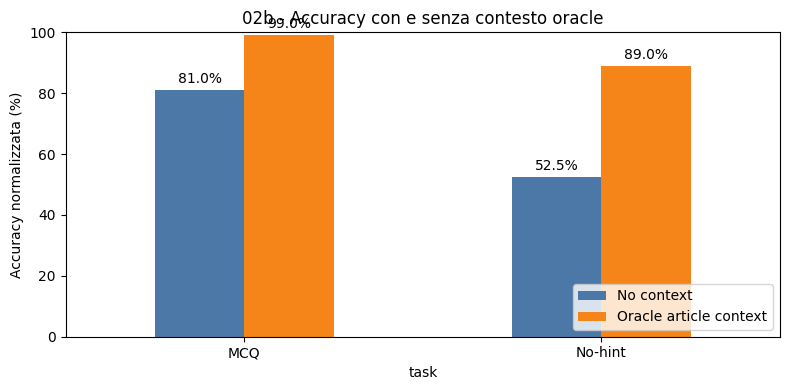

In [7]:
plot_df = pd.DataFrame({
    'task': ['MCQ', 'No-hint'],
    'No context': [summary['mcq_no_context']['accuracy'], summary['no_hint_no_context']['accuracy']],
    'Oracle article context': [summary['mcq_oracle_context']['accuracy'], summary['no_hint_oracle_context']['accuracy']],
}).set_index('task')

ax = (plot_df * 100).plot(kind='bar', figsize=(8, 4), color=['#4C78A8', '#F58518'], rot=0)
ax.set_title('02b - Accuracy con e senza contesto oracle')
ax.set_ylabel('Accuracy normalizzata (%)')
ax.set_ylim(0, 100)
ax.legend(loc='lower right')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)
plt.tight_layout()
plt.show()

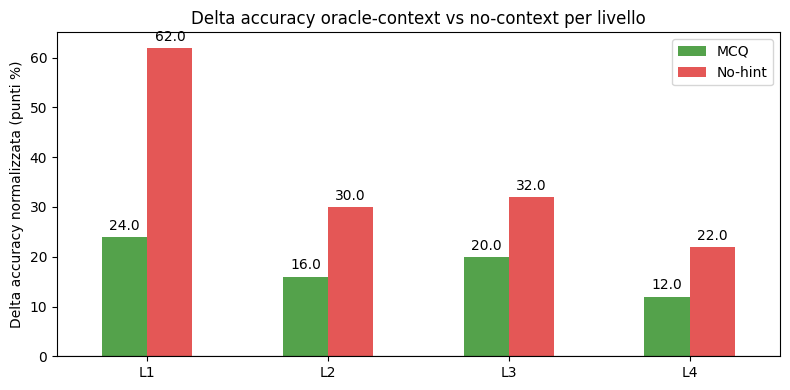

In [8]:
levels = sorted(set(level_df['level'])) if not level_df.empty else []
if levels:
    by_level_plot = pd.DataFrame(index=levels)
    for task, no_name, ctx_name in [
        ('MCQ', 'mcq_no_context', 'mcq_oracle_context'),
        ('No-hint', 'no_hint_no_context', 'no_hint_oracle_context'),
    ]:
        no_values = summary[no_name]['by_level']
        ctx_values = summary[ctx_name]['by_level']
        by_level_plot[task] = [
            ((ctx_values.get(level, {}).get('accuracy') or 0) - (no_values.get(level, {}).get('accuracy') or 0)) * 100
            for level in levels
        ]
    ax = by_level_plot.plot(kind='bar', figsize=(8, 4), color=['#54A24B', '#E45756'], rot=0)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title('Delta accuracy oracle-context vs no-context per livello')
    ax.set_ylabel('Delta accuracy normalizzata (punti %)')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f', padding=3)
    plt.tight_layout()
    plt.show()

## Ispezione Casi

Le tabelle seguenti aiutano a controllare manualmente dove il contesto migliora, lascia invariata o peggiora la risposta. Per no-hint il confronto usa il punteggio del judge `0-2`.

In [9]:
def compare_rows(no_context: pd.DataFrame, oracle_context: pd.DataFrame, score_col: str, prediction_col: str) -> pd.DataFrame:
    cols = ['qid', 'level', 'question', prediction_col, score_col, 'error']
    merged = no_context[cols].merge(
        oracle_context[cols],
        on=['qid', 'level', 'question'],
        suffixes=('_no_context', '_oracle_context'),
    )
    merged['delta'] = merged[f'{score_col}_oracle_context'].fillna(-1) - merged[f'{score_col}_no_context'].fillna(-1)
    return merged.sort_values(['delta', 'qid'], ascending=[False, True])

mcq_comparison = compare_rows(results['mcq_no_context'], results['mcq_oracle_context'], 'score', 'predicted_label')
no_hint_comparison = compare_rows(results['no_hint_no_context'], results['no_hint_oracle_context'], 'judge_score', 'predicted_answer')

print('MCQ improved')
display(mcq_comparison[mcq_comparison['delta'] > 0].head(5))
print('MCQ unchanged')
display(mcq_comparison[mcq_comparison['delta'] == 0].head(5))
print('MCQ degraded')
display(mcq_comparison[mcq_comparison['delta'] < 0].head(5))

print('No-hint improved')
display(no_hint_comparison[no_hint_comparison['delta'] > 0].head(5))
print('No-hint unchanged')
display(no_hint_comparison[no_hint_comparison['delta'] == 0].head(5))
print('No-hint degraded')
display(no_hint_comparison[no_hint_comparison['delta'] < 0].head(5))


MCQ improved


,qid,level,question,predicted_label_no_context,score_no_context,error_no_context,predicted_label_oracle_context,score_oracle_context,error_oracle_context,delta
4,eval-0005,L1,Da quanti membri è composta la Consulta region...,A,0,None,D,1,None,1
6,eval-0007,L3,"Io ho 32 anni, sono un soggetto privato che no...",C,0,None,B,1,None,1
10,eval-0011,L3,Un accordo di programma può essere stipulato a...,A,0,None,D,1,None,1
11,eval-0012,L4,I Comuni sono liberi di adottare i propri rego...,C,0,None,D,1,None,1
16,eval-0017,L1,Con quale atto giuridico vengono concessi i co...,A,0,None,C,1,None,1


MCQ unchanged


,qid,level,question,predicted_label_no_context,score_no_context,error_no_context,predicted_label_oracle_context,score_oracle_context,error_oracle_context,delta
0,eval-0001,L1,Quali sono gli organi dell'azienda Usl?,D,1,None,D,1,None,0
1,eval-0002,L2,Come si attua la programmazione sanitaria regi...,E,1,None,E,1,None,0
2,eval-0003,L3,Cosa accade in caso di vacanza dell'ufficio o ...,D,1,None,D,1,None,0
3,eval-0004,L4,Quali istituzioni partecipano alla politica so...,B,1,None,B,1,None,0
5,eval-0006,L2,Con quali dei seguenti strumenti la Regione in...,A,1,None,A,1,None,0


MCQ degraded


...

,qid,level,question,predicted_answer_no_context,judge_score_no_context,error_no_context,predicted_answer_oracle_context,judge_score_oracle_context,error_oracle_context,delta
0,eval-0001,L1,Quali sono gli organi dell'azienda Usl?,Gli organi dell'Azienda USL (Azienda Unità San...,0,None,Gli organi dell'azienda USL sono: il direttore...,2,None,2
4,eval-0005,L1,Da quanti membri è composta la Consulta region...,La Consulta regionale per la mobilità ciclisti...,0,None,La Consulta regionale per la mobilità ciclisti...,2,None,2
6,eval-0007,L3,"Io ho 32 anni, sono un soggetto privato che no...",Il contributo regionale per l'acquisto di un v...,0,None,Il contributo regionale ammonta al 50% della s...,2,None,2
8,eval-0009,L1,Qual è lo strumento per la pianificazione urba...,Lo strumento per la pianificazione urbanistica...,0,None,Lo strumento per la pianificazione urbanistica...,2,None,2
20,eval-0021,L1,Che cos'è il GAP?,Il GAP (Gruppo di Azione Finanziaria) è un'org...,0,None,Il GAP (gioco d’azzardo patologico) è la patol...,2,None,2


No-hint unchanged


,qid,level,question,predicted_answer_no_context,judge_score_no_context,error_no_context,predicted_answer_oracle_context,judge_score_oracle_context,error_oracle_context,delta
5,eval-0006,L2,Con quali dei seguenti strumenti la Regione in...,La Regione incentiva la mobilità sostenibile m...,2,None,La Regione incentiva la mobilità sostenibile p...,2,None,0
9,eval-0010,L2,Per effettuare una trasformazione urbanistica ...,Per effettuare una trasformazione urbanistica ...,2,None,Per effettuare una trasformazione urbanistica ...,2,None,0
10,eval-0011,L3,Un accordo di programma può essere stipulato a...,"Sì, un accordo di programma può essere stipula...",0,None,"Sì, un accordo di programma può essere stipula...",0,None,0
12,eval-0013,L1,Quale organo regionale determina i criteri e l...,L'organo regionale competente è la Giunta regi...,2,None,La Giunta regionale determina i criteri e le m...,2,None,0
15,eval-0016,L4,Una società cooperativa che esercita attività ...,"Sì, una società cooperativa che esercita attiv...",2,None,"Sì, una società cooperativa che esercita attiv...",2,None,0


No-hint degraded


,qid,level,question,predicted_answer_no_context,judge_score_no_context,error_no_context,predicted_answer_oracle_context,judge_score_oracle_context,error_oracle_context,delta
11,eval-0012,L4,I Comuni sono liberi di adottare i propri rego...,"Sì, i Comuni sono liberi di adottare propri re...",1,None,"Sì, i Comuni sono liberi di adottare propri re...",0,None,-1
26,eval-0027,L3,Quali dei seguenti materiali deve utilizzare u...,La normativa italiana non elenca materiali spe...,2,None,Una struttura deve utilizzare acque minerali n...,1,None,-1
44,eval-0045,L1,Che cosa sono le “piante officinali” ai sensi ...,"Ai sensi dell’art. 2, comma 1, lettera a), del...",1,None,"La Legge regionale 16 febbraio 2011, n. 2 non ...",0,None,-1
99,eval-0100,L4,Con quali provvedimenti la Regione viene in ai...,La Regione può intervenire a sostegno delle im...,2,None,"La Regione Valle d'Aosta ha previsto, con la L...",1,None,-1
13,eval-0014,L2,Quali delle seguenti produzioni non è una prod...,La domanda non fornisce l'elenco delle produzi...,2,None,La produzione di sabots di Ayas è una produzio...,0,None,-2
